#### One of the fundamental steps of an unsupervised learning algorithm is to determine the number of clusters into which the data may be divided. The silhouette algorithm is one of the many algorithms to determine the optimal number of clusters for an unsupervised learning technique. In the Silhouette algorithm, we assume that the data has already been clustered into k clusters by a clustering technique(Typically K-Means Clustering technique). Then for each data point, we define the following:- C(i) -The cluster assigned to the ith data point |C(i)| - The number of data points in the cluster assigned to the ith data point a(i) - It gives a measure of how well assigned the ith data point is to it's cluster 

#### Silhouette refers to a method of interpretation and validation of consistency within clusters of data. Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique.
#### Its value ranges from -1 to 1.

#### Also if our value goes to near 1 we consider this the best clustering happened we should use this .
#### And if our value goes to near -1 we consider this the bad clustering happened and we can't consider this .

# Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Import dataset (using Iris dataset)

In [2]:
dataset = pd.read_csv("/Users/bhavyakansal/Datasets/iris_unlabelled.csv")
dataset.head(3)

,sepal_lenght,sepal_width,petal_lengh,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


# Lets identify realtionship between data in graphical form to check whether the data is linear separable or not because K Means clustering works best on linear data 

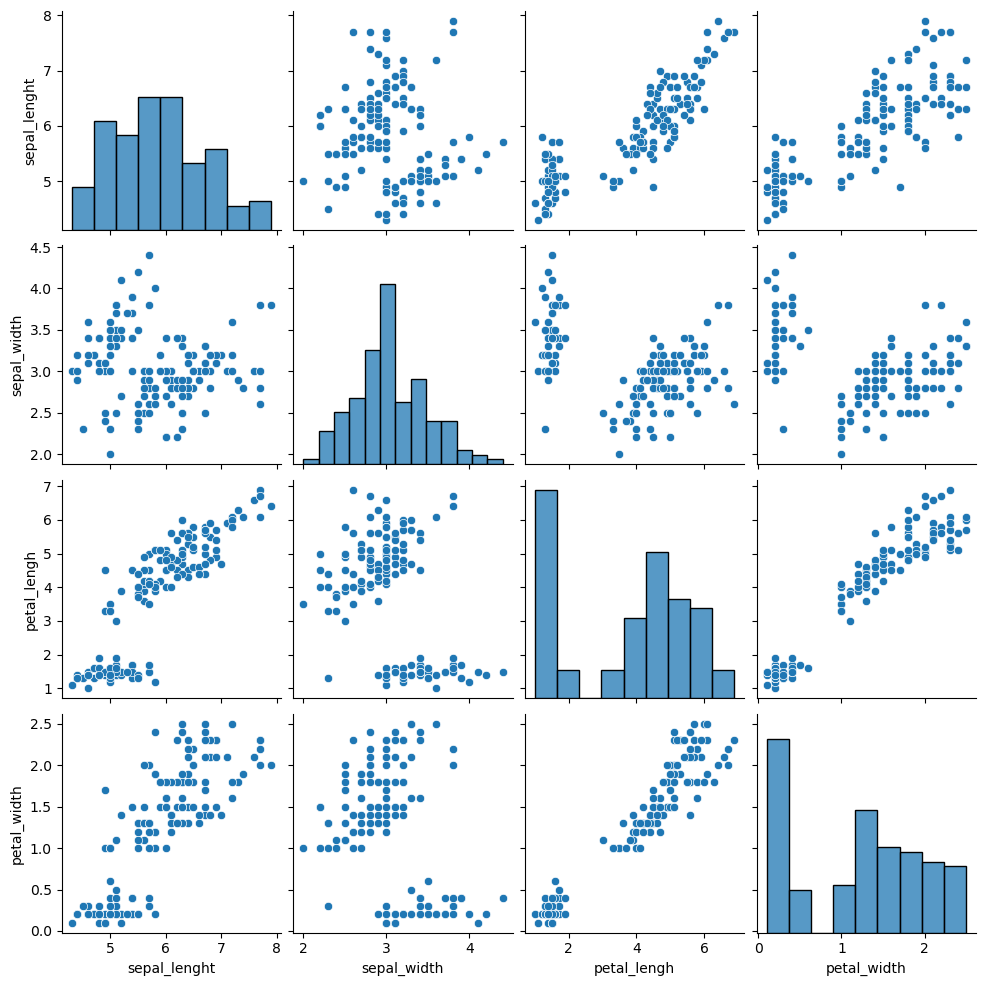

In [3]:
sns.pairplot(data=dataset)
plt.show()

In [4]:
from sklearn.cluster import KMeans

In [5]:
wcss = []

for i in range (2,21):
    km = KMeans(n_clusters= i , init="k-means++")
    km.fit(dataset)
    wcss.append(km.inertia_)

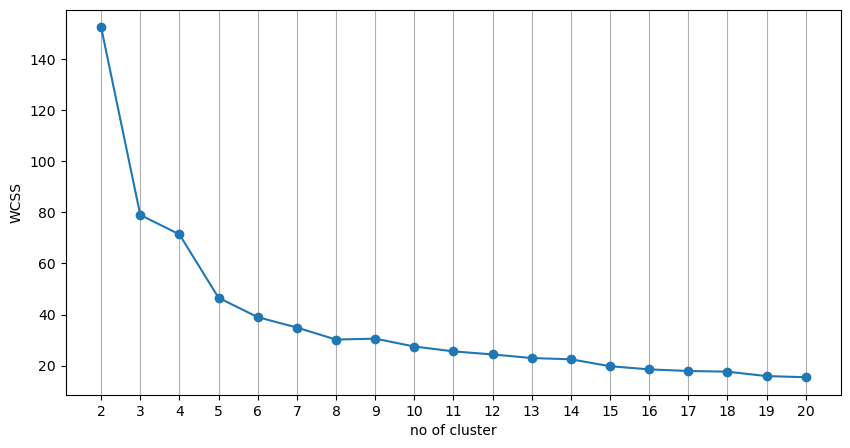

In [6]:
plt.figure(figsize=(10,5))
plt.plot(range(2, 21), wcss , marker="o")
plt.xlabel("no of cluster")
plt.xticks(range(2, 21))
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()

In [7]:
kmn = KMeans(n_clusters=3)
dataset["Predict"] = kmn.fit_predict(dataset)

In [8]:
dataset.head(10)

,sepal_lenght,sepal_width,petal_lengh,petal_width,Predict
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


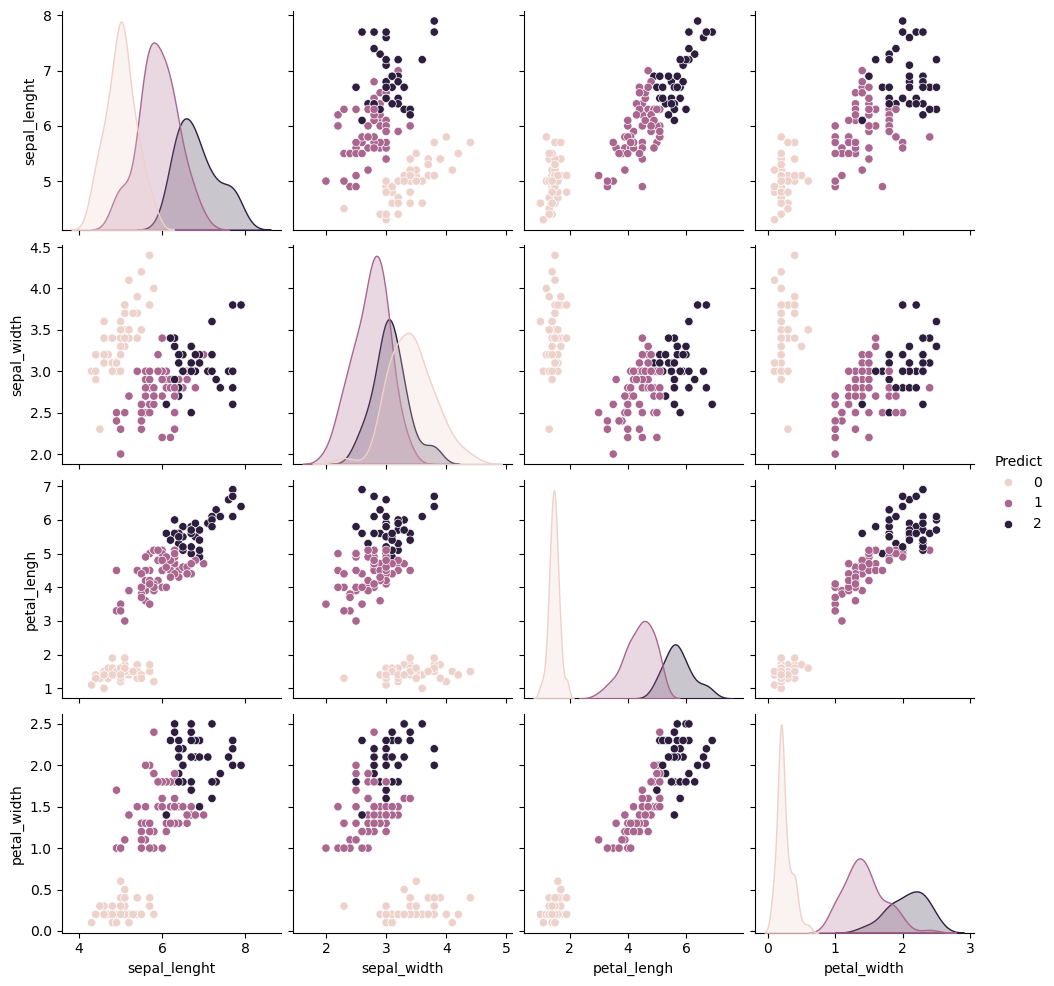

In [9]:
sns.pairplot(data= dataset , hue="Predict")
plt.savefig("Predict.jpg")
plt.show()

### Now as we see on above graph we can see that we have one confusion on in it that cluster 3 is correct or 4 we don't have any surety in it so lets use silhouette clustering algorithm to find out the best number of cluster and also the cluster we have found is correct or not .

In [10]:
from sklearn.metrics import silhouette_score

In [15]:
ss=[]
no_cluster = [j for j in range(2,21)]
for i in range (2,21):
    km1 = KMeans(n_clusters= i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset , labels=km1.labels_))

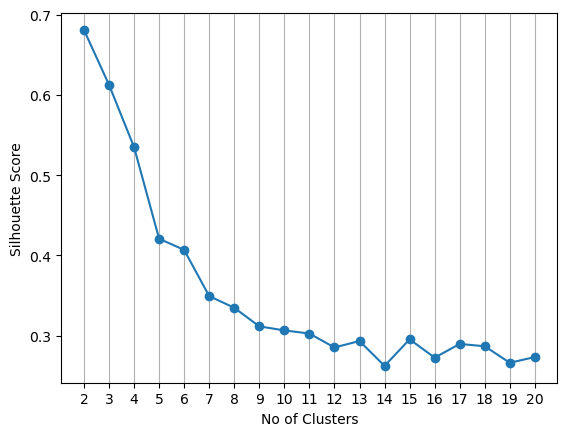

In [30]:
plt.plot(no_cluster , ss , marker="o")
plt.xlabel("No of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(no_cluster)
plt.grid(axis="x")
plt.show()

### Like we can see when we use Wcss we got no of clusters = 3 , whereas when we use Silhouette Score we got no of clusters = 2. That menas in this particular dataset minimum number of clusters are 2 because if we see pair plot of original dataset we see two separate clusters are made but we can also use 3 number of clusters because 2 is the minimum no of clusters 